# **Milestone** | Exploratory Analysis of Olympic Athletes


<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5c/Olympic_rings_without_rims.svg/2560px-Olympic_rings_without_rims.svg.png" alt="The Olympic Rings" width="320"/>
</div>



# Introduction

In this Milestone, you will analyze a dataset containing information on Olympic medalists from 1896 to 2016. Your goal is to apply practical data analysis skills to explore trends, clean inconsistencies, and generate insights that will support data-driven journalism about the athletes, countries, and events that have shaped Olympic history.


### Dataset Description

You will use the `olympics.csv` dataset in the `datasets` folder to complete your analysis. Every row represents one athlete's participation in a specific Olympic event. The dataset contains the following columns:

* **ID**: A unique identifying number of each athlete
* **Name**: The name of each athlete
* **Sex**: M or F
* **Age**: The age of an athlete, in years
* **Height**: The height of an athlete, in centimeters
* **Weight**: The weight of an athlete, in kilograms
* **Team**: The name of the athlete’s team. Not always the name of a country.
* **NOC**: National Olympic Committee’s 3 letter code
* **Games**: Year and season
* **Season**: Summer or Winter
* **City**: Host city
* **Sport**: The  or category of olympic event/activity
* **Event**: specific event within a sport, e.g. Men’s 400 meters breaststroke.
* **Medal**: Gold, Silver, Bronze
* **Region**: Name of athlete’s country


To start, import the pandas library, load the data into a DataFrame and preview the first 5 rows.

In [91]:
# import the pandas library
import pandas as pd

# load the data into a dataframe
df = pd.read_csv("datasets/olympics.csv")

# preview the dataframe
print(df.head())

   ID                      Name Sex   Age  Height  Weight            Team  \
0   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
1  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         Finland   
2  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         Finland   
3  16  Juhamatti Tapio Aaltonen   M  28.0   184.0    85.0         Finland   
4  17   Paavo Johannes Aaltonen   M  28.0   175.0    64.0         Finland   

   NOC        Games  Year  Season       City       Sport  \
0  DEN  1900 Summer  1900  Summer      Paris  Tug-Of-War   
1  FIN  1920 Summer  1920  Summer  Antwerpen    Swimming   
2  FIN  1920 Summer  1920  Summer  Antwerpen    Swimming   
3  FIN  2014 Winter  2014  Winter      Sochi  Ice Hockey   
4  FIN  1948 Summer  1948  Summer     London  Gymnastics   

                                    Event   Medal   region  
0             Tug-Of-War Men's Tug-Of-War    Gold  Denmark  
1  Swimming Men's 200 metres Breaststroke  Bronze  Fin

## Task 1: Data Inspection
Start by inspecting the dataset to understand its structure and the types of questions you can ask. You'll familiarize yourself with the data columns and initial statistics.

In [92]:
# Inspect the numbers of rows and columns
print(f"This data set is comprised of {df.shape[0]} rows, with {df.shape[1]} columns.")

This data set is comprised of 39783 rows, with 16 columns.


In [93]:
# Print out all the column names
print(f"The names of the columns are:\n{df.columns.tolist()}")

The names of the columns are:
['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region']


In [94]:
# Inspect column data types, null values, and other info
print(f"Here is the information of these datasets:\n{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39783 entries, 0 to 39782
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      39783 non-null  int64  
 1   Name    39783 non-null  object 
 2   Sex     39783 non-null  object 
 3   Age     39051 non-null  float64
 4   Height  31072 non-null  float64
 5   Weight  30456 non-null  float64
 6   Team    39783 non-null  object 
 7   NOC     39783 non-null  object 
 8   Games   39783 non-null  object 
 9   Year    39783 non-null  int64  
 10  Season  39783 non-null  object 
 11  City    39783 non-null  object 
 12  Sport   39783 non-null  object 
 13  Event   39783 non-null  object 
 14  Medal   39783 non-null  object 
 15  region  39774 non-null  object 
dtypes: float64(3), int64(2), object(11)
memory usage: 4.9+ MB
Here is the information of these datasets:
None


As you're reviewing the .info() output from the dataset, you should notice there are missing values some of the columns! Ask ChatGPT to recommend approaches for dealing with missing data in your analysis.

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> I’m working with a dataset of Olympic medalists, and I’ve noticed some missing values in columns like Age, Height, Weight, and Region. I’m planning to ignore these missing values. Is this a reasonable approach for my analysis, or are there any important considerations I should be aware of before doing so?


  </span>
</div>

In [95]:
# Use unique() to examine the types of medals in the dataset.
print(f"Unique medal types: {df['Medal'].unique()}")

Unique medal types: ['Gold' 'Bronze' 'Silver']


## Task 2: Data Cleaning
Now that we have a sense of the data, let's clean it to make sure it's ready for analysis.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>When renaming/dropping columns, make sure to assign the result back to the dataframe to ensure that the new column names <em> replace </em> the old ones in your dataset.
</span>
</div>

In [96]:
# Rename 'NOC' column to 'CountryCode'
# Rename 'region' column to 'Country'
df = df.rename(columns={'NOC': 'CountryCode', 'region': 'Country'})
# preivew the dataframe again
print(f"Preview with renamed columns:\n{df.head()}")

Preview with renamed columns:
   ID                      Name Sex   Age  Height  Weight            Team  \
0   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
1  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         Finland   
2  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         Finland   
3  16  Juhamatti Tapio Aaltonen   M  28.0   184.0    85.0         Finland   
4  17   Paavo Johannes Aaltonen   M  28.0   175.0    64.0         Finland   

  CountryCode        Games  Year  Season       City       Sport  \
0         DEN  1900 Summer  1900  Summer      Paris  Tug-Of-War   
1         FIN  1920 Summer  1920  Summer  Antwerpen    Swimming   
2         FIN  1920 Summer  1920  Summer  Antwerpen    Swimming   
3         FIN  2014 Winter  2014  Winter      Sochi  Ice Hockey   
4         FIN  1948 Summer  1948  Summer     London  Gymnastics   

                                    Event   Medal  Country  
0             Tug-Of-War Men's Tug-Of-War  

In [97]:
# Remove the 'Team' column
df = df.drop(columns=['Team'])
# preivew the dataframe again
print(f"Preview with 'Team' column dropped:\n{df.head()}")

Preview with 'Team' column dropped:
   ID                      Name Sex   Age  Height  Weight CountryCode  \
0   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN         DEN   
1  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         FIN   
2  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         FIN   
3  16  Juhamatti Tapio Aaltonen   M  28.0   184.0    85.0         FIN   
4  17   Paavo Johannes Aaltonen   M  28.0   175.0    64.0         FIN   

         Games  Year  Season       City       Sport  \
0  1900 Summer  1900  Summer      Paris  Tug-Of-War   
1  1920 Summer  1920  Summer  Antwerpen    Swimming   
2  1920 Summer  1920  Summer  Antwerpen    Swimming   
3  2014 Winter  2014  Winter      Sochi  Ice Hockey   
4  1948 Summer  1948  Summer     London  Gymnastics   

                                    Event   Medal  Country  
0             Tug-Of-War Men's Tug-Of-War    Gold  Denmark  
1  Swimming Men's 200 metres Breaststroke  Bronze  Finland  
2  Swimming

## Task 3: Data Analysis

It's time to analyze the data to uncover factual information about athletes, medals, and events! You'll explore:
- Youngest and oldest medalists
- Medal count
- Number of unique events
- Average age of medalists
- Top 10 winningest countries by total medal count



**1.** What is the **youngest** age of an Olympic medalist?

In [98]:
# youngest age
youngest_age = df['Age'].min()
print(f"The youngest age of an Olympic medalist is {youngest_age}.")

The youngest age of an Olympic medalist is 10.0.


**2.** What is the **oldest** age of an Olympic medalist?

In [99]:
# oldest age
oldest_age = df['Age'].max()
print(f"The oldest age of an Olympic medalist is {oldest_age}.")

The oldest age of an Olympic medalist is 73.0.


**3.** Summarize the number of medals awarded by type. How many of each medal were awarded?

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>Think about which column contains the medal types, and how you could <em>count</em> the number of times each <em>value</em> appears.
</span>
</div>

In [100]:
# number of medals awarded by type
medal_counts = df['Medal'].value_counts()
print(f"Number of medals awarded by type: \n{medal_counts}")

Number of medals awarded by type: 
Gold      13372
Bronze    13295
Silver    13116
Name: Medal, dtype: int64


**4.** How many (unique) events are there?

In [101]:
# Number of unique events
unique_events = df['Event'].nunique()
print(f"There are {unique_events} unique events.")

There are 756 unique events.


**5.** How many (unique) sports are there?

In [102]:
# Number of unique sports
unique_sports = df['Sport'].nunique()
print(f"There are {unique_sports} unique sports.")

There are 66 unique sports.


**6.** What is the average age of an Olympic medalist? Round the age to the nearest whole number.

In [103]:
# average age of an Olympic medalist?
avg_age = round(df['Age'].mean())
print(f"The average age of an Olympic medalist, rounded to the nearest whole number, is {avg_age}.")

The average age of an Olympic medalist, rounded to the nearest whole number, is 26.


**7A.** Among the 10 oldest medalists, what are the most common sports?


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>Start by sorting the data so the oldest athletes appear first. Then look only at a small slice of the data — you don’t need to analyze the full dataset to answer the question.
</span>
</div>

In [104]:
# most common sports among the 10 oldest medalists
oldest_medalists = df.sort_values(by='Age', ascending=False).head(10)
print(f"The most common sports for the 10 Oldest Olympic Medalists are:\n{oldest_medalists[['Name', 'Age', 'Sport']]}")

The most common sports for the 10 Oldest Olympic Medalists are:
                                                Name   Age             Sport
6072   John (Herbert Crawford-) Copley (Williamson-)  73.0  Art Competitions
8279                                      Jozu Dupon  72.0  Art Competitions
33952                              Oscar Gomer Swahn  72.0          Shooting
21901                         Charles William Martin  71.0           Sailing
21902                         Charles William Martin  71.0           Sailing
12614                        Letitia Marion Hamilton  69.0  Art Competitions
34707                                   Oskar Thiede  69.0  Art Competitions
21198                   Frederick William MacMonnies  68.0  Art Competitions
8340                           Samuel Harding Duvall  68.0           Archery
25165                                 Louis Noverraz  66.0           Sailing


**7B.** To get a clearer view of the sports these athletes participated in, focus on the `Sport` column. After identifying the top 10 oldest athletes, count how many times each sport appears among them. This is a more precise way to identify the most common sports among oldest medalists!


In [105]:
# most common sports among the 10 oldest medalists with .value_counts
common_sports_oldest = oldest_medalists['Sport'].value_counts()
print(f"The most common sports among the 10 oldest medalists are:\n{common_sports_oldest}")

The most common sports among the 10 oldest medalists are:
Art Competitions    5
Sailing             3
Shooting            1
Archery             1
Name: Sport, dtype: int64


**8.** What are the 10 winningest countries in total medal count?

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>You'll need to count the number of times each country appears in the dataset but only display the top 10!
</span>
</div>

In [106]:
# What are the 10 winningest countries in total medal count?
top_countries = df['Country'].value_counts().head(10)
print(f"The top 10 winningest countries (by total medals) are:\n{top_countries}")

The top 10 winningest countries (by total medals) are:
USA          5637
Russia       3947
Germany      3756
UK           2068
France       1777
Italy        1637
Sweden       1536
Canada       1352
Australia    1349
Hungary      1135
Name: Country, dtype: int64


**9.** How many medals have been awarded in the sport of trampolining?

In [107]:
# Trampolining medals
trampoline_medals = df[df['Sport'] == 'Trampolining']['Medal'].count()
print(f"There have been {trampoline_medals} total medals awarded in Trampolining." )

There have been 30 total medals awarded in Trampolining.


## Task 4: Find the Story
Now that you’ve explored the dataset and uncovered some key facts about athletes, events, and countries, it’s time to think like a data journalist.

Based on your findings:

- What trend, pattern, or outlier stood out to you?

- What topic would you pitch as the focus of a data-driven reporting article?

- Why do you think it’s interesting or important to explore further?

Write a short pitch (3–5 sentences) describing:

1. The angle you would pursue

2. What specific data points support it

3. What additional information you might want to gather

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> I’ve explored a dataset about Olympic medalists and found [insert key findings]. I want to pitch a story based on these findings. Can you suggest a few ways to frame the story to make it interesting for a general audience?


  </span>
</div>


I would like to pursue the change in medal sports as the age of Olympians increases. With an average age of 26 the vast majority of Olympians are barely older than teenagers, with very few old olympians. Among these older Olympians, they tend to focus on sports such as Arts and Sailing, sports that typically do not require the youth and spryness of things such as distance running or weightlifting. By sorting the data so that we can see the the average ages of the Olympians competing in each sport, we can get an idea of the differing requirements of these sports, and how they effect competitors.


## LevelUp
Explore additional questions to dive deeper into the dataset and see how the insights you uncover might influence your pitch or reporting. These extra credit tasks offer a chance to refine your understanding and discover new angles for potential stories 😎



**1.** Use a combination of filters to find out how many gold medals were awarded to the United States?

In [108]:
# gold medals awarded to the United States
us_gold_medals = df[(df['Country'] == 'USA') & (df['Medal'] == 'Gold')].shape[0]
print(f"There have been {us_gold_medals} gold medals awarded to the United States.")

There have been 2638 gold medals awarded to the United States.


**2.** List the Olympic Games in dataset, starting with the most recent

In [109]:
# Olympic Games in the dataset
olympic_games = df['Games'].unique()
olympic_games_sorted = sorted(olympic_games, reverse=True)
print(f"The following is a list of Olympic Games organized by their recency:\n{olympic_games_sorted}")

The following is a list of Olympic Games organized by their recency:
['2016 Summer', '2014 Winter', '2012 Summer', '2010 Winter', '2008 Summer', '2006 Winter', '2004 Summer', '2002 Winter', '2000 Summer', '1998 Winter', '1996 Summer', '1994 Winter', '1992 Winter', '1992 Summer', '1988 Winter', '1988 Summer', '1984 Winter', '1984 Summer', '1980 Winter', '1980 Summer', '1976 Winter', '1976 Summer', '1972 Winter', '1972 Summer', '1968 Winter', '1968 Summer', '1964 Winter', '1964 Summer', '1960 Winter', '1960 Summer', '1956 Winter', '1956 Summer', '1952 Winter', '1952 Summer', '1948 Winter', '1948 Summer', '1936 Winter', '1936 Summer', '1932 Winter', '1932 Summer', '1928 Winter', '1928 Summer', '1924 Winter', '1924 Summer', '1920 Summer', '1912 Summer', '1908 Summer', '1906 Summer', '1904 Summer', '1900 Summer', '1896 Summer']


**3.** What is the average medalist height in the most recent Winter Olympics. Format your answer into Feet' Inches''.

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> "How can I convert 175 inches into feet and inches in Python? Can you show me the code for that?"
  </span>
</div>

In [110]:
# average medalist height in the most recent Winter Olympics
latest_winter_year = df[df['Season'] == 'Winter']['Games'].max()
latest_winter_df = df[(df['Season'] == 'Winter') & (df['Games'] == latest_winter_year)]
avg_height_cm_winter = latest_winter_df['Height'].mean()
avg_height_in_winter = avg_height_cm_winter / 2.54
feet_winter = int(avg_height_in_winter // 12)
inches_winter = int(round(avg_height_in_winter % 12))
print(f"The average medalist height in the most recent Winter Olympics was {feet_winter}' {inches_winter}''.")

The average medalist height in the most recent Winter Olympics was 5' 9''.


**4.** What is the average medalist **weight** in the most recent Winter Olympics. Round the average weight to the nearest 2 decimals.

In [111]:
# Average medalist weight in the most recent Winter Olympics
avg_weight_winter = round(latest_winter_df['Weight'].mean(), 2)
print(f"The average medalist weight in the most recent Winter Olympics was {avg_weight_winter} kg.")

The average medalist weight in the most recent Winter Olympics was 72.21 kg.


**5.** What is the average medalist **height** in the most recent Summer Olympics. Format your answer into Feet' Inches''.

In [112]:
# Average medalist height in the most recent Summer Olympics
latest_summer_year = df[df['Season'] == 'Summer']['Games'].max()
latest_summer_df = df[(df['Season'] == 'Summer') & (df['Games'] == latest_summer_year)]
avg_height_cm_summer = latest_summer_df['Height'].mean()
avg_height_in_summer = avg_height_cm_summer / 2.54
feet_summer = int(avg_height_in_summer // 12)
inches_summer = int(round(avg_height_in_summer % 12))
print(f"The average medalist height in the most recent Summer Olympics was {feet_summer}' {inches_summer}''.")


The average medalist height in the most recent Summer Olympics was 5' 10''.


**6.** What is the average medalist **weight** in the most recent Summer Olympics. Round the average weight to the nearest 2 decimals.

In [113]:
# Average medalist weight in the most recent Summer Olympics
avg_weight_summer = round(latest_summer_df['Weight'].mean(), 2)
print(f"The average medalist weight in the most recent Summer Olympics was {avg_weight_summer} kg.")

The average medalist weight in the most recent Summer Olympics was 73.96 kg.


**7.** Import `plotly.express` and create a bar chart to visualize the top 10 countries with the most medals by using the data you assigned in Task 3.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong> You'll need to asssign top 10 winningest countries table from Task 3 to it's own variable!
</span>
</div>



In [114]:
# Import plotly express library
import plotly.express as px

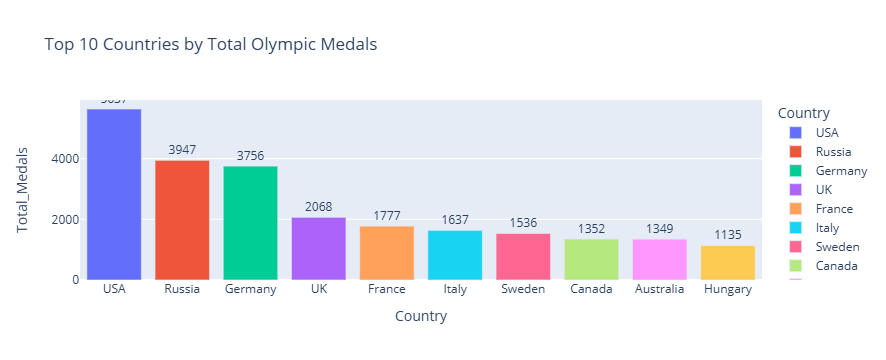

In [115]:
# Asssign top 10 winningest countries table to a variable
top10_countries = df['Country'].value_counts().head(10).reset_index()
top10_countries.columns = ['Country', 'Total_Medals']

# Visualize the table as a bar chart
fig = px.bar(top10_countries, x='Country', y='Total_Medals',
             title='Top 10 Countries by Total Olympic Medals',
             color='Country', text='Total_Medals')
fig.update_traces(textposition='outside')
fig.show()